# PS3: Design a survey with a Fisher forecast



In [1]:
# Setup. Makes the shared helper module lsscosmo.py importable.
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
import lsscosmo as lc
print('lsscosmo loaded from', lc.__file__)


lsscosmo loaded from /Users/shadab/Documents/Projects/ictp-cosmology-lss-lectures/notebooks/lsscosmo.py



**Problem Set**

You have a fixed number of fibre-hours. Spend them to constrain dark energy
best. The parameters are $\{\Omega_m, w_0, w_a\}$. The observables are the BAO
distance ratios $D_M(z)/r_d$ and $D_H(z)/r_d$ in ten redshift bins over
$0<z<2.5$, plus the CMB acoustic scale $100\,r_d/D_M(z_\ast)$ (this is how
"$r_d$ from the CMB" enters and anchors the high-redshift geometry).

The figure of merit is $\mathrm{FoM}=1/\sqrt{\det\mathrm{Cov}(w_0,w_a)}$
(bigger is better). Two levers are yours:

- the **sky area**, which sets the comoving volume per bin (more area at fixed
  budget means lower density per bin);
- the **distribution of objects across redshift**, $N(z)$, subject to the
  fibre-hour budget. Higher-redshift targets are fainter and cost more exposure
  time, so they are "expensive".

**Think About:** the FoM-versus-area curves for a few $N(z)$ shapes, your
chosen design, the resulting $\sigma(w_0),\sigma(w_a)$, and the written answer.

*Simplifications (stated so you know the toy's edges):* $H_0$ and $r_d$ are held
fixed at CMB-calibrated values; the CMB enters only through the acoustic-scale
term; the per-bin BAO error is an approximate scaling with effective volume,
not a full covariance.


In [2]:
# --- fixed cosmology scale and the fiducial parameters ---
rd = 147.05          # Mpc, sound horizon from the CMB (held fixed)
H0 = 67.36; hh = H0/100.0    # H0 fixed (CMB-calibrated)
fid = dict(Om=0.3153, w0=-1.0, wa=0.0)
z_edges = np.linspace(0.0, 2.5, 11)      # 10 bins
z_cen = 0.5*(z_edges[1:] + z_edges[:-1])
Z_STAR = 1089.9      # redshift of last scattering (CMB acoustic scale)

def cosmo_of(p):
    return lc.Cosmology(Om=p['Om'], h=hh, w0=p['w0'], wa=p['wa'])

def observables(p):
    # 10 bins x {DM/rd, DH/rd}, then the CMB acoustic scale 100 rd/DM(z*)
    c = cosmo_of(p)
    dm = np.array([float(c.DM(z))/rd for z in z_cen])
    dh = np.array([float(c.DH(z))/rd for z in z_cen])
    theta = 100.0*rd/float(c.DM(Z_STAR))
    return np.concatenate([np.ravel(np.column_stack([dm, dh])), [theta]])

obs_fid = observables(fid)
CMB_ERR = obs_fid[-1]*0.0003          # 0.03% on the acoustic scale

c0 = cosmo_of(fid)
dm_edge = np.array([float(c0.DM(z)) for z in z_edges])                 # Mpc
Pbao = np.array([float(c0.power_spectrum_nowiggle(0.14, z)) for z in z_cen])  # (Mpc/h)^3
print('P at BAO scale per bin (falls with z via growth):')
print(np.round(Pbao).astype(int))

P at BAO scale per bin (falls with z via growth):
[3072 2358 1830 1444 1159  947  786  662  564  486]


In [3]:
# --- survey model: volume, BAO errors, exposure cost, and the Fisher matrix ---
def bin_volume_gpc3(area_deg2):
    fsky = area_deg2/41252.96
    shell = fsky*(4*np.pi/3.0)*(dm_edge[1:]**3 - dm_edge[:-1]**3)   # Mpc^3
    return shell * hh**3 / 1e9                                       # (Gpc/h)^3

def bao_frac_errors(nbar, V_gpc3, P):
    # approximate fractional errors on DM/rd and DH/rd from effective volume
    Veff = np.maximum(V_gpc3*(nbar*P/(1.0 + nbar*P))**2, 1e-6)
    sig_dm = 0.008*np.sqrt(10.0/Veff)
    return sig_dm, 1.6*sig_dm

dl = (1.0 + z_cen)*np.array([float(c0.DM(z)) for z in z_cen])
exposure = (dl/dl[np.argmin(abs(z_cen - 0.8))])**2   # per-object cost, ~1 at z=0.8
T_BUDGET = 1.0e8                                       # total fibre-hours (arbitrary units)

def design_from_shape(shape):
    # turn a relative N(z) shape into object counts that spend the full budget
    shape = np.array(shape, float); shape = shape/shape.sum()
    alpha = T_BUDGET/np.sum(shape*exposure)
    return alpha*shape

def fisher(area_deg2, N_per_bin):
    V = bin_volume_gpc3(area_deg2)
    nbar = N_per_bin/(V*1e9)                          # (h/Mpc)^3
    sdm, sdh = bao_frac_errors(nbar, V, Pbao)
    dm0 = obs_fid[0:2*len(z_cen):2]; dh0 = obs_fid[1:2*len(z_cen):2]
    errs = []
    for i in range(len(z_cen)):
        errs += [dm0[i]*sdm[i], dh0[i]*sdh[i]]
    errs = np.array(errs + [CMB_ERR])
    keys = ['Om', 'w0', 'wa']; steps = {'Om': 0.003, 'w0': 0.02, 'wa': 0.05}
    cols = []
    for k in keys:
        pp = dict(fid); pp[k] += steps[k]
        cols.append((observables(pp) - obs_fid)/steps[k])
    J = np.array(cols).T
    return J.T @ np.diag(1.0/errs**2) @ J, keys

def forecast(area_deg2, N_per_bin):
    F, keys = fisher(area_deg2, N_per_bin)
    Cov = np.linalg.inv(F)
    i0, i1 = keys.index('w0'), keys.index('wa')
    fom = 1.0/np.sqrt(np.linalg.det(Cov[np.ix_([i0, i1], [i0, i1])]))
    return fom, dict(zip(keys, np.sqrt(np.diag(Cov))))

f0, s0 = forecast(6000.0, design_from_shape(np.ones(10)))
print('example (6000 deg2, flat N):  FoM=%.1f  sigma(w0)=%.3f  sigma(wa)=%.2f'
      % (f0, s0['w0'], s0['wa']))

example (6000 deg2, flat N):  FoM=16.1  sigma(w0)=0.172  sigma(wa)=0.94


### Task. Explore the design space
The budget is fixed. Scan several **sky areas** and a few **$N(z)$ shapes**
(flat, tilted low, tilted high, concentrated at mid-$z$), compute the FoM for
each with `forecast(area, design_from_shape(shape))`, plot FoM versus area with
one line per shape, and record the best design. Then print $\sigma(w_0)$ and
$\sigma(w_a)$ for your best design.

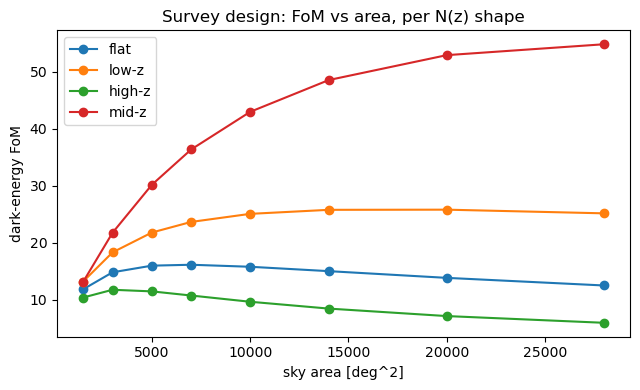

best design: shape=mid-z, area=28000 deg2, FoM=54.8
  sigma(Om)=0.004  sigma(w0)=0.097  sigma(wa)=0.54


In [4]:
areas = np.array([1500, 3000, 5000, 7000, 10000, 14000, 20000, 28000], float)
shapes = {
    'flat':   np.ones(10),
    'low-z':  np.linspace(2.0, 0.5, 10),
    'high-z': np.linspace(0.5, 2.0, 10),
    'mid-z':  np.exp(-((z_cen - 1.0)/0.5)**2),
}
plt.figure(figsize=(6.5, 4))
best = (None, None, -1.0)
for name, shp in shapes.items():
    N = design_from_shape(shp)
    foms = np.array([forecast(a, N)[0] for a in areas])
    plt.plot(areas, foms, marker='o', label=name)
    j = int(np.argmax(foms))
    if foms[j] > best[2]:
        best = (name, areas[j], foms[j])
plt.xlabel('sky area [deg^2]'); plt.ylabel('dark-energy FoM')
plt.title('Survey design: FoM vs area, per N(z) shape')
plt.legend(); plt.tight_layout(); plt.show()

print('best design: shape=%s, area=%.0f deg2, FoM=%.1f' % best)
fom_b, sig_b = forecast(best[1], design_from_shape(shapes[best[0]]))
print('  sigma(Om)=%.3f  sigma(w0)=%.3f  sigma(wa)=%.2f'
      % (sig_b['Om'], sig_b['w0'], sig_b['wa']))

**You can double your telescope time. Spend it on more objects per bin (higher
density) or more sky (more volume)? What sky area and $N(z)$ distribution did
you choose, and why?** Point to your FoM curves: where is the interior optimum
in area, and what is happening to $\bar nP$ on either side of it? Explain why the
best $N(z)$ shape is not flat (think about the exposure cost of high-$z$ targets,
the volume available at low $z$, and where the redshift lever arm for $w_a$ comes
from, given that the CMB already anchors $z_\ast$).